<details>
<summary><b>Info</b></summary>

**Last Execution:** 2026-08-04

| Package | Version |
|---------|---------|
| **nnsight** | **0.8** |
| Python | 3.12.13 |
| torch | 2.13.0+cu126 |
| transformers | 5.15.0 |

</details>

# The Jacobian Lens

## Introduction

🔬 The **Jacobian lens** (J-lens) characterizes an intermediate residual-stream
activation by its *first-order causal effect on the model's output*, averaged over a
corpus of contexts.

The [logit lens](../tutorials/probing/logit_lens.ipynb) reads an intermediate activation by
pretending the rest of the model is the identity: it unembeds $h_\ell$ directly. That works
late in the network and reads mostly noise in the middle. The J-lens replaces the implicit
identity with a **fitted linear transport** $J_\ell$ — the corpus-averaged Jacobian of the
final block's output with respect to the output of block $\ell$:

$$J_\ell = \mathbb{E}_{\text{prompt}}\left[\frac{1}{|V|}\sum_{t \in V}\ \sum_{t' \in V,\ t' \ge t} \frac{\partial h_{\text{final},\,t'}}{\partial h_{\ell,\,t}}\right]$$

where $V$ is the set of valid token positions. The readout then uses the model's own
final norm and unembedding:

$$\mathrm{lens}(h_\ell) = W_U\,\mathrm{norm}(J_\ell\, h_\ell)$$

The logit lens is the special case $J_\ell = I$; the J-lens is its causal, corpus-averaged
correction. Because $J_\ell$ is linear, the rows of $W_U J_\ell$ are residual-stream
*directions* attached to single vocabulary tokens — so the lens is not only a reading
instrument but a set of concept vectors you can steer with, ablate, and swap.

📗 Introduced in [*Verbalizable Representations Form a Global Workspace in Language Models*](https://transformer-circuits.pub/2026/workspace/index.html)
(Gurnee et al., Transformer Circuits Thread, 2026). The reference implementation is
[`anthropics/jacobian-lens`](https://github.com/anthropics/jacobian-lens) (Apache-2.0);
pre-fitted lenses for 38 open models are published at
[`neuronpedia/jacobian-lens`](https://huggingface.co/neuronpedia/jacobian-lens), with an
interactive version at [neuronpedia.org/jlens](https://www.neuronpedia.org/jlens).

In this notebook we

1. load a published lens for `gemma-2-2b` and read it with a single `nnsight` trace,
2. compare it to the logit lens on a two-hop prompt with an *unspoken* intermediate,
3. causally swap one concept for another (France → China) in lens coordinates,
4. steer along a J-lens direction, and
5. **fit our own lens from scratch** with `nnsight`'s backward API, and check it against
   the published artifact.

One convenient detail: published lenses are fitted on **raw HuggingFace activations**.
`nnsight` runs the HuggingFace module tree unmodified — no weight folding, no rewritten
residual basis — so the artifacts drop straight in with nothing to reconcile.

## Setup

If using Colab, install NNsight:
```
!pip install -U nnsight
```

In [1]:
try:
    import google.colab
    is_colab = True
except ImportError:
    is_colab = False

if is_colab:
    !pip install -U nnsight

In [2]:
import torch
import nnsight
from nnsight import TransformersModel
from huggingface_hub import hf_hub_download

`google/gemma-2-2b` is a gated repository — accept the license on the model page and log in
with `huggingface-cli login` (or set `HF_TOKEN`) before running the next cell.

In [3]:
MODEL_NAME = "google/gemma-2-2b"

model = TransformersModel(MODEL_NAME, dtype=torch.bfloat16, device_map="auto", dispatch=True)

layers = model.model.layers
n_layers = model.config.num_hidden_layers
d_model = model.config.hidden_size
device = model.lm_head.weight.device

print(f"{MODEL_NAME}: {n_layers} layers, d_model={d_model}, device={device}")

google/gemma-2-2b: 26 layers, d_model=2304, device=cuda:0


## 1. Loading a published lens

A lens artifact is one $[d_{model}, d_{model}]$ matrix per source layer. The final layer is
never fitted — its transport to itself is the identity by construction — so a 26-layer model
has 25 matrices.

In [4]:
LENS_PATH = hf_hub_download(
    "neuronpedia/jacobian-lens",
    filename="gemma-2-2b/jlens/Salesforce-wikitext/gemma-2-2b_jacobian_lens.pt",
    revision="a4114d7752d11eb546e6cf372213d7e75526d3a1",
)
artifact = torch.load(LENS_PATH, map_location="cpu", weights_only=True)

J = {int(layer): matrix.float().to(device) for layer, matrix in artifact["J"].items()}

print(f"source layers : {min(J)}..{max(J)} ({len(J)} matrices)")
print(f"d_model       : {artifact['d_model']}")
print(f"fitted on     : {artifact['n_prompts']} wikitext prompts")

source layers : 0..24 (25 matrices)
d_model       : 2304
fitted on     : 454 wikitext prompts


## 2. Reading the lens

The readout is transport-then-unembed, and both halves are ordinary tensor algebra we can
run *inside* the trace — one forward pass for every layer at once, with only the reduced
logits leaving the trace.

Two details specific to Gemma-2. Its final norm is `model.model.norm`, and its output logits
are soft-capped at 30 (`logits = cap * tanh(logits / cap)`) *after* `lm_head`, outside the
module we can call. Soft-capping is monotone, so it never changes a ranking — we apply it
anyway so lens values are on the same scale as the model's own logits.

In [5]:
SOFTCAP = model.config.final_logit_softcapping
UNEMBED_DTYPE = model.lm_head.weight.dtype

def unembed(hidden):
    """The model's own final norm + unembedding + logit soft cap."""
    logits = model.lm_head(model.model.norm(hidden.to(UNEMBED_DTYPE))).float()
    return SOFTCAP * torch.tanh(logits / SOFTCAP)

def readout(prompt, position=-1, use_jacobian=True):
    """Per-layer vocabulary logits for one prompt position, in a single forward pass."""
    with model.trace(prompt):
        per_layer = nnsight.save([])
        for layer in range(n_layers):
            hidden = layers[layer].output[:, position, :]
            if use_jacobian and layer in J:
                hidden = hidden.float() @ J[layer].T
            per_layer.append(unembed(hidden)[0])
        model_logits = model.output.logits[0, position].float().save()
    return torch.stack(list(per_layer)), model_logits

### A two-hop prompt with an unspoken intermediate

*"The currency used in the country shaped like a boot"* requires an intermediate step —
**Italy** — that never appears in the prompt, and never appears in the model's output either.
If the intermediate is represented anywhere, it is in the middle of the residual stream.

In [6]:
PROMPT = "Fact: The currency used in the country shaped like a boot is"

jacobian_logits, model_logits = readout(PROMPT)
logit_lens_logits, _ = readout(PROMPT, use_jacobian=False)

decode = lambda token_id: model.tokenizer.decode([token_id])

print(f"{'layer':>5} | {'J-lens top-1':<20} | logit lens top-1")
for layer in [4, 8, 13, 17, 21, 24, 25]:
    print(
        f"{layer:>5} | {decode(jacobian_logits[layer].argmax().item())!r:<20}"
        f" | {decode(logit_lens_logits[layer].argmax().item())!r}"
    )
print("model output:", repr(decode(model_logits.argmax().item())))

layer | J-lens top-1         | logit lens top-1
    4 | ' anything'          | ' is'
    8 | '\n\n\n'             | ' is'
   13 | 'LookAnd'            | ' is'
   17 | 'LookAnd'            | ' called'
   21 | ' euro'              | ' called'
   24 | ' the'               | ' the'
   25 | ' the'               | ' the'
model output: ' the'


The two lenses agree at the top of the model — by layer 24 the transport is nearly the
identity — and disagree in the middle, which is the interesting part. The logit lens tracks
surface continuations of the prompt (`' is'`, `' called'`) all the way up; the J-lens gets to
the *answer concept* (`' euro'`) around layer 21, well before the model commits to a token.

Neither lens says anything at layer 4 (the paper's "sensory" band), and the recurring code-ish
tokens in the middle J-lens readouts (`'LookAnd'`) are a known signature of this particular
lens on `gemma-2-2b` — a reminder that a corpus-averaged linear transport is an approximation,
not a decoder.

Top-1 tokens are a coarse summary. Tracking the *rank* of a few pinned tokens across depth
shows the concept trajectory more honestly:

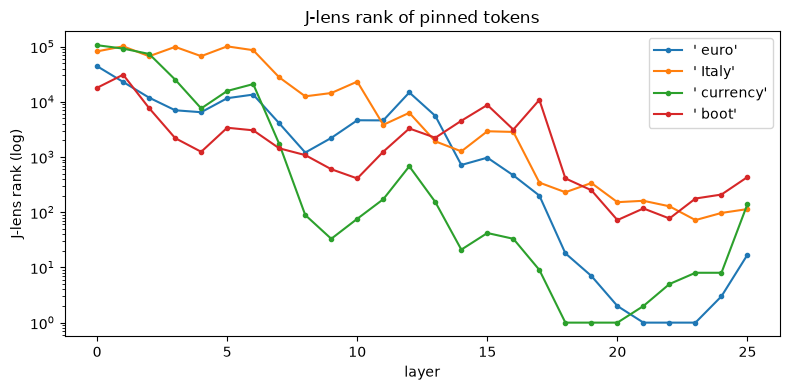

In [7]:
import matplotlib.pyplot as plt

def single_token_id(text):
    ids = model.tokenizer.encode(text, add_special_tokens=False)
    assert len(ids) == 1, f"{text!r} is not a single token: {ids}"
    return ids[0]

PINNED = [" euro", " Italy", " currency", " boot"]

fig, ax = plt.subplots(figsize=(8, 4))
for token in PINNED:
    token_id = single_token_id(token)
    ranks = [
        int((jacobian_logits[layer] > jacobian_logits[layer, token_id]).sum()) + 1
        for layer in range(n_layers)
    ]
    ax.plot(range(n_layers), ranks, marker="o", markersize=3, label=repr(token))

ax.set(
    yscale="log",
    xlabel="layer",
    ylabel="J-lens rank (log)",
    title="J-lens rank of pinned tokens",
)
ax.legend()
plt.tight_layout()
plt.show()

`' euro'` — the answer — reaches rank 1 around layer 20 and holds it for four layers, then
slips back to the teens at layer 25 as the lens converges to the model's own distribution,
where the *immediate* next token is the grammatical `' the'`. The answer is decided well
before it is emitted, and the emitted token is not the answer.

`' Italy'` is the interesting line. It is in neither the prompt nor the output, and it improves
by three orders of magnitude across the second half of the model, settling around rank 100 —
the unspoken intermediate of the two-hop question, visible in a lens that reads causal effect
rather than surface form. `' currency'`, which *is* in the prompt, is the control: it is
already near the top by layer 8.

## 3. Swapping concepts in lens coordinates

Because $J_\ell$ is linear, each vocabulary token has a residual-stream direction at every
layer — its **J-lens vector**, the row of $W_U J_\ell$ pulled back into layer-$\ell$
coordinates:

$$v_t^{(\ell)} = J_\ell^{\top} W_U[:, t]$$

In [8]:
def lens_vectors(tokens, layer):
    """J-lens direction(s) for vocabulary token(s), in layer-`layer` residual coordinates."""
    token_ids = [single_token_id(token) if isinstance(token, str) else token for token in tokens]
    return model.lm_head.weight[token_ids].float() @ J[layer]

The paper's *flexible generalization* test exchanges two concepts in these coordinates. With
$V = [v_s, v_t]$, read the activation's lens coordinates $c = V^{+} h$ (pseudoinverse) and
write back

$$h \leftarrow h + \alpha\, V\,(\sigma(c) - c)$$

where $\sigma$ exchanges the two coordinates. Everything orthogonal to $\mathrm{span}\{v_s, v_t\}$
is left alone — this is a targeted edit, not a wholesale replacement. The swap is clamped at
every token position across an intermediate band (layers 10–24 ≈ the paper's 38–92% workspace
band).

In [9]:
def swap_basis(source_token, target_token, band):
    """Pre-compute (V, V⁺) per layer for a source→target concept swap."""
    basis = {}
    for layer in band:
        V = lens_vectors([source_token, target_token], layer).T  # [d_model, 2]
        basis[layer] = (V, torch.linalg.pinv(V))
    return basis

def run(prompt, swap=None, steer=None, alpha=1.0):
    """One forward pass, optionally with lens-space interventions on a band of layers."""
    with model.trace(prompt):
        for layer in range(n_layers):
            if swap is not None and layer in swap:
                V, V_pinv = swap[layer]
                hidden = layers[layer].output.float()
                coords = hidden @ V_pinv.T                          # [batch, pos, 2]
                delta = alpha * ((coords[..., [1, 0]] - coords) @ V.T)
                layers[layer].output[:] = (hidden + delta).to(layers[layer].output.dtype)
            if steer is not None and layer in steer:
                hidden = layers[layer].output.float()
                scale = alpha * hidden.norm(dim=-1).median()
                layers[layer].output[:] = (
                    hidden + scale * steer[layer]
                ).to(layers[layer].output.dtype)
        logits = model.output.logits[0, -1].float().save()
    return logits

def top_tokens(logits, k=5):
    return [decode(token_id) for token_id in logits.topk(k).indices.tolist()]

In [10]:
BAND = range(10, 25)
france_to_china = swap_basis(" France", " China", BAND)

for prompt in ["Most people in France speak", "The capital of France is"]:
    print(repr(prompt))
    print("  baseline :", top_tokens(run(prompt)))
    print("  swapped  :", top_tokens(run(prompt, swap=france_to_china)))

'Most people in France speak'
  baseline : [' French', ' English', ' a', ' at', ' the']
  swapped  : [' Chinese', ' English', ' a', ' some', ' the']
'The capital of France is'
  baseline : [' a', ' the', ' one', ' also', ' home']
  swapped  : [' a', ' the', ' one', ' also', ' home']


In [11]:
for prompt, answer in [
    ("Most people in France speak", " Chinese"),
    ("The capital of France is", " Beijing"),
]:
    answer_id = single_token_id(answer)
    baseline = run(prompt)
    swapped = run(prompt, swap=france_to_china)
    baseline_rank = int((baseline > baseline[answer_id]).sum()) + 1
    swapped_rank = int((swapped > swapped[answer_id]).sum()) + 1
    print(f"{prompt!r}: rank of {answer!r} {baseline_rank} -> {swapped_rank}")

'Most people in France speak': rank of ' Chinese' 346 -> 1
'The capital of France is': rank of ' Beijing' 991 -> 9


At $\alpha=1$ the language template flips top-1 outright (`' French'` → `' Chinese'`), and the
China-appropriate answer on the capital template jumps hundreds of ranks. The same two-vector
edit redirects *two different* downstream computations — the broadcast claim the paper makes
about its workspace band.

It is worth being precise about what did and did not happen: on this small base model the
capital template's top-1 is a filler word even unperturbed, so the swap moves ` Beijing` up
without winning. The paper reports 42/48 top-1 successes for country swaps on Claude Sonnet
4.5, and that doubling to $\alpha=2$ recovers some $\alpha=1$ failures. On `gemma-2-2b`,
$\alpha=2$ instead overshoots into *verbalizing* the injected concept (top-1 becomes
`' China'` itself), so $\alpha=1$ is the better default here.

## 4. Steering along a J-lens direction

The same vectors work as steering directions. Following the reference implementation's
protocol, we add the *unit* lens vector scaled by the activation's own median residual norm,
so the perturbation is norm-matched to the stream it is injected into:

$$h \leftarrow h + \alpha \cdot \mathrm{median}\|h\| \cdot \hat{v}_t$$

The median (not the mean) keeps attention-sink positions, whose residual norms run orders of
magnitude above everything else, from setting the scale.

In [12]:
def steering_directions(token, band):
    directions = {}
    for layer in band:
        vector = lens_vectors([token], layer)[0]
        directions[layer] = vector / vector.norm()
    return directions

paris = steering_directions(" Paris", range(10, 21))

prompt = "This weekend I am planning a trip to"
print("baseline :", top_tokens(run(prompt)))
print("steered  :", top_tokens(run(prompt, steer=paris, alpha=2.0)))

baseline : [' the', ' a', ' my', ' visit', ' see']
steered  : [' paris', ' Paris', 'Paris', ' París', 'paris']


Projecting a direction *out* instead — $h \leftarrow h - (h \cdot \hat{v})\hat{v}$ — is the
corresponding ablation, and slots into the same `run` helper.

## 5. Fitting a lens with nnsight

Published artifacts only cover 38 models. Fitting is a vector-Jacobian product, which is
exactly what a backward pass computes — so `nnsight` can fit a lens directly, with no
additional machinery.

The estimator, per prompt:

1. one forward pass, with the prompt **replicated `dim_batch` times** along the batch axis;
2. `ceil(d_model / dim_batch)` backward passes. Each one plants a one-hot cotangent for one
   output dimension at *every* valid target position at once — causal attention then
   guarantees that the gradient arriving at source position $t$ is already the sum over
   target positions $t' \ge t$, with no explicit masking;
3. average the resulting rows over valid source positions.

Positions are valid if they are past a leading skip (16 — early positions are attention sinks
with atypical residual statistics) and are not the final position. The whole thing is
deterministic: no sampling, no optimization.

We fit `gpt2` here because it is small, ungated, and — usefully — has a published lens we can
check ourselves against.

In [13]:
from datasets import load_dataset

gpt2 = TransformersModel("openai-community/gpt2", dtype=torch.bfloat16,
                         device_map="auto", dispatch=True)
blocks = gpt2.transformer.h
gpt2_layers = gpt2.config.n_layer
gpt2_d_model = gpt2.config.n_embd

SOURCE_LAYERS = list(range(gpt2_layers - 1))
TARGET_LAYER = gpt2_layers - 1
SKIP_FIRST, MAX_SEQ_LEN, DIM_BATCH = 16, 128, 32

# Freezing the parameters roots the autograd graph at the residual stream instead of at the
# weights: the backward pass then computes only the activation gradients we actually want.
for parameter in gpt2.parameters():
    parameter.requires_grad_(False)

In [14]:
def jacobian_for_prompt(text):
    """Exact per-prompt Jacobian rows for every source layer, via batched one-hot cotangents."""
    input_ids = gpt2.tokenizer(
        text, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LEN
    ).input_ids
    seq_len = input_ids.shape[1]
    if seq_len <= SKIP_FIRST + 1:
        return None
    valid = torch.arange(SKIP_FIRST, seq_len - 1)
    n_passes = -(-gpt2_d_model // DIM_BATCH)  # ceil division

    with gpt2.trace(input_ids.expand(DIM_BATCH, -1)):
        # Nothing requires grad once the parameters are frozen, so we root the graph here.
        blocks[0].output.requires_grad_(True)
        sources = [blocks[layer].output for layer in SOURCE_LAYERS]
        target = blocks[TARGET_LAYER].output

        rows = nnsight.save([])
        for index in range(n_passes):
            start = index * DIM_BATCH
            width = min(DIM_BATCH, gpt2_d_model - start)
            batch = torch.arange(width, device=target.device)
            cotangent = torch.zeros_like(target)
            cotangent[batch[:, None], valid.to(target.device)[None, :], start + batch[:, None]] = 1.0

            with (target * cotangent).sum().backward(retain_graph=index < n_passes - 1):
                for layer in reversed(SOURCE_LAYERS):  # gradients arrive in reverse order
                    rows.append(sources[layer].grad[:width, valid, :].float().mean(dim=1).cpu())

    jacobians = {layer: torch.zeros(gpt2_d_model, gpt2_d_model) for layer in SOURCE_LAYERS}
    chunks = iter(rows)
    for index in range(n_passes):
        start = index * DIM_BATCH
        width = min(DIM_BATCH, gpt2_d_model - start)
        for layer in reversed(SOURCE_LAYERS):
            jacobians[layer][start:start + width, :] = next(chunks)
    return jacobians

Two `nnsight` details make the loop above work:

- **`(target * cotangent).sum().backward(...)`** is the vector-Jacobian product. `nnsight`
  interleaves the backward pass the same way it interleaves the forward, so `.grad` on a
  captured activation is that pass's gradient — it does not accumulate across passes.
  `retain_graph=True` on every pass but the last keeps the graph alive for the next cotangent.
- **Gradients must be read in reverse-forward order** — last layer first — for the same
  reason activations must be read in forward order.

In [15]:
dataset = load_dataset(
    "Salesforce/wikitext", "wikitext-103-raw-v1", split="train", streaming=True
)
prompts = [row["text"][:2000] for row in dataset.take(2000) if len(row["text"]) > 600][:64]

accumulator = {layer: torch.zeros(gpt2_d_model, gpt2_d_model) for layer in SOURCE_LAYERS}
n_fitted = 0
for text in prompts:
    per_prompt = jacobian_for_prompt(text)
    if per_prompt is None:
        continue
    for layer in SOURCE_LAYERS:
        accumulator[layer] += per_prompt[layer]
    n_fitted += 1

fitted = {layer: accumulator[layer] / n_fitted for layer in SOURCE_LAYERS}
print(f"fitted on {n_fitted} prompts")

fitted on 64 prompts


The published `gpt2` lens used the same corpus and hyperparameters, stopping at 277 prompts
when its convergence criterion was met. Ours saw 64. If the estimator is right, the two should
already be close:

In [16]:
published_path = hf_hub_download(
    "neuronpedia/jacobian-lens",
    filename="gpt2-small/jlens/Salesforce-wikitext/gpt2_jacobian_lens.pt",
)
published = {
    int(layer): matrix.float()
    for layer, matrix in torch.load(published_path, map_location="cpu", weights_only=True)["J"].items()
}

print(f"{'layer':>5} {'cosine':>8} {'rel. error':>11}")
for layer in SOURCE_LAYERS:
    ours, theirs = fitted[layer].flatten(), published[layer].flatten()
    cosine = torch.nn.functional.cosine_similarity(ours, theirs, dim=0).item()
    rel_error = ((ours - theirs).norm() / theirs.norm()).item()
    print(f"{layer:>5} {cosine:8.4f} {rel_error:11.4f}")

layer   cosine  rel. error
    0   0.9860      0.1672
    1   0.9861      0.1677
    2   0.9888      0.1513
    3   0.9895      0.1468
    4   0.9903      0.1413
    5   0.9914      0.1339
    6   0.9934      0.1163
    7   0.9953      0.0987
    8   0.9966      0.0845
    9   0.9978      0.0674
   10   0.9993      0.0404


Cosine similarity above 0.98 everywhere, tightening toward 0.999 at the top of the model,
from a quarter of the prompts. Fit quality saturates fast — the reference implementation
reports ~100 prompts of 128 tokens as usable, and the residual disagreement here is
overwhelmingly *scale* on the early layers, where the corpus average is still tightening.

Reading through our own lens, for a prompt the fit never saw:

In [17]:
GPT2_UNEMBED_DTYPE = gpt2.lm_head.weight.dtype

def gpt2_readout(prompt, lens, position=-1):
    with gpt2.trace(prompt):
        per_layer = nnsight.save([])
        for layer in range(gpt2_layers):
            hidden = blocks[layer].output[:, position, :]
            if layer in lens:
                hidden = hidden.float() @ lens[layer].to(hidden.device).T
            per_layer.append(gpt2.lm_head(gpt2.transformer.ln_f(hidden.to(GPT2_UNEMBED_DTYPE)))[0].float())
    return torch.stack(list(per_layer))

GPT2_PROMPT = "The Eiffel Tower is in the city of"
ours = gpt2_readout(GPT2_PROMPT, fitted)
theirs = gpt2_readout(GPT2_PROMPT, published)
logit_lens = gpt2_readout(GPT2_PROMPT, {})

print(f"{'layer':>5} | {'our lens':<16} | {'published lens':<16} | logit lens")
for layer in range(gpt2_layers):
    print(
        f"{layer:>5} | {gpt2.tokenizer.decode([ours[layer].argmax().item()])!r:<16}"
        f" | {gpt2.tokenizer.decode([theirs[layer].argmax().item()])!r:<16}"
        f" | {gpt2.tokenizer.decode([logit_lens[layer].argmax().item()])!r}"
    )

layer | our lens         | published lens   | logit lens
    0 | 'ModLoader'      | 'ModLoader'      | ' the'
    1 | 'ModLoader'      | 'ModLoader'      | ' the'
    2 | 'ModLoader'      | 'ModLoader'      | ' the'
    3 | ' castles'       | ' tremend'       | ' the'
    4 | ' castles'       | ' tremend'       | ' the'
    5 | ' laun'          | ' castles'       | ' the'
    6 | ' Constantinople' | ' tremend'       | ' East'
    7 | ' Constantinople' | ' Constantinople' | ' Ing'
    8 | ' Frie'          | ' Constantinople' | ' Rome'
    9 | ' Cologne'       | ' Cologne'       | ' London'
   10 | ' Cologne'       | ' Cologne'       | ' London'
   11 | ' London'        | ' London'        | ' London'


The two lenses agree at 9 of 12 layers and disagree only on near-ties in the noisy middle —
a 64-prompt fit is already reading the same thing as a 277-prompt one.

The content is worth a look on its own. `gpt2` gets this prompt wrong: it answers `' London'`.
But under the J-lens the *city* band opens up at layer 6 (`' Constantinople'`, `' Cologne'`,
`' London'`) while the logit lens is still reading `' the'` — the type of the answer is
settled several layers before any particular city is, and the model's error is a choice
within that band rather than a failure to form it.

Fits over disjoint prompt slices are just means, so they combine exactly: average the matrices
weighted by prompt count and you get the lens you would have fitted on the union. That is how
the published artifacts parallelize across GPUs, and it is three lines of `torch` here.

## Conclusion

🎉 The J-lens is a small amount of linear algebra wrapped around one thing `nnsight` is
built for — getting at, and writing to, the residual stream. Reading a lens is a
transport-then-unembed inside a single trace; intervening with it is an in-place write on a
band of block outputs; fitting one is a loop of vector-Jacobian products through
`tensor.backward()`.

Related: [Logit Lens](../tutorials/probing/logit_lens.ipynb) for the $J_\ell = I$ baseline,
[Model Steering](../tutorials/steering/dict_learning.ipynb) for other ways to get concept
directions, and [Gradients](../../features/3_gradients.ipynb) for the backward API used in
the fit.

## References

- Gurnee et al., [*Verbalizable Representations Form a Global Workspace in Language Models*](https://transformer-circuits.pub/2026/workspace/index.html), Transformer Circuits Thread, 2026
- Reference implementation: [`anthropics/jacobian-lens`](https://github.com/anthropics/jacobian-lens) (Apache-2.0)
- Published lenses: [`neuronpedia/jacobian-lens`](https://huggingface.co/neuronpedia/jacobian-lens) · interactive: [neuronpedia.org/jlens](https://www.neuronpedia.org/jlens)
- nostalgebraist, [*Interpreting GPT: the Logit Lens*](https://www.lesswrong.com/posts/AcKRB8wDpdaN6v6ru/interpreting-gpt-the-logit-lens), 2020